In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns


df = pd.read_csv("../data/store_data.csv", encoding="latin-1")
print(df)


(10064, 21)


In [18]:
print(df.shape)

(10064, 21)


In [19]:
df.head

<bound method NDFrame.head of        Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0           1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1           2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2           3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3           4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4           5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...       ...             ...         ...         ...             ...   
10059    1281  CA-2016-160815    9/5/2016    9/6/2016     First Class   
10060    7699  CA-2017-151799  12/14/2017  12/18/2017  Standard Class   
10061    8597  CA-2014-111934    5/5/2014    5/7/2014     First Class   
10062    4962  CA-2014-156587    3/7/2014    3/8/2014     First Class   
10063    3998  CA-2015-105627    3/8/2015   3/12/2015  Standard Class   

      Customer ID      Customer Name      Segment        Country  \
0        CG-12520        

In [ ]:
df.tail()

In [ ]:
df.info()

In [ ]:
df.describe()

In [124]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object

In [ ]:
df.nunique()

In [ ]:
#using this method instead of df.select_dtypes(include="object").columns 
#to see if the column is categorical
#because the type of category are shown as 'object'
df["Category"].unique()


In [ ]:
#checking numerical columns
df.select_dtypes(['int64','float64']).columns

Index(['Row ID', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [ ]:
#missing values count
missing_count = df.isna().sum()

#% of missing values
missing_prct = df.isna().mean().round(2) * 100 

print(missing_count)
print(missing_prct)

In [54]:

df.duplicated().sum()

np.int64(34)

c:\Users\Youcode\Desktop\DEV Ai\DataStore360\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


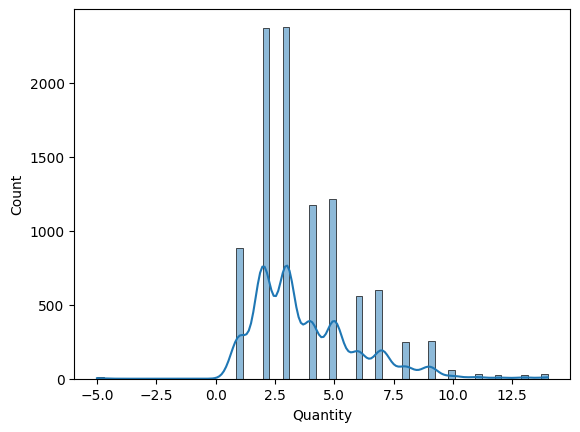

In [117]:
#Numerical distributions
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Quantity'], kde=True)
plt.show()



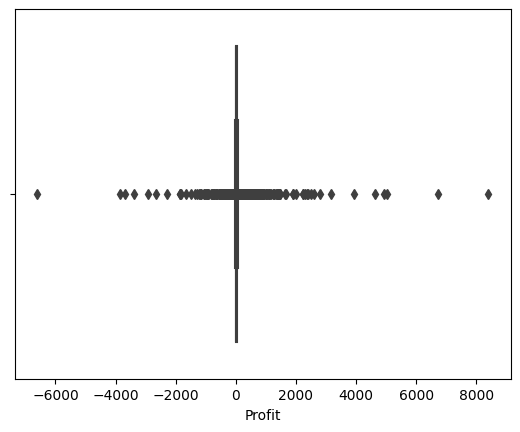

In [118]:
sns.boxplot(x=df["Profit"])
plt.show()

In [ ]:
sns.boxplot(x=df["Discount"])
plt.show()

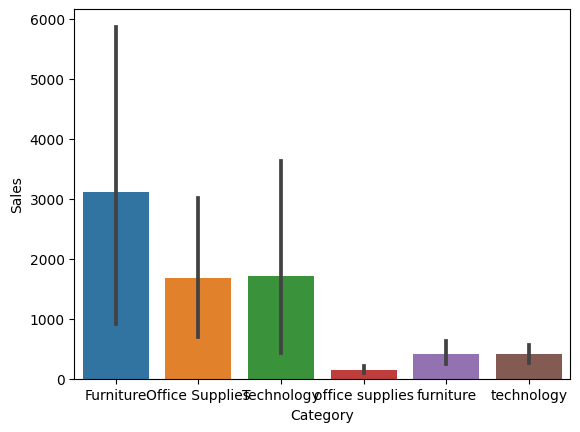

In [ ]:
#Categorical distributions

sns.barplot(x=df['Category'], y=df['Sales'])
plt.show()


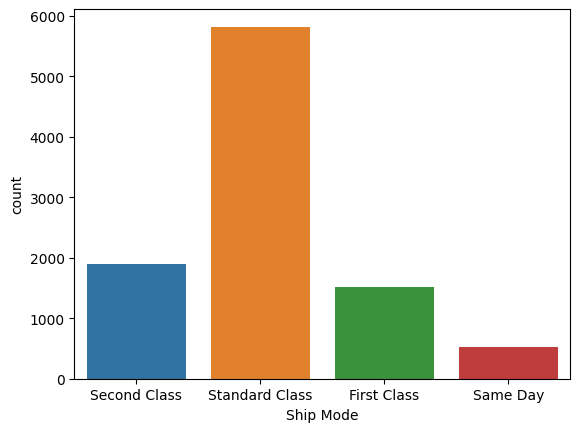

In [120]:
sns.countplot(data=df , x='Ship Mode')
plt.show()

<Axes: xlabel='count', ylabel='Sub-Category'>

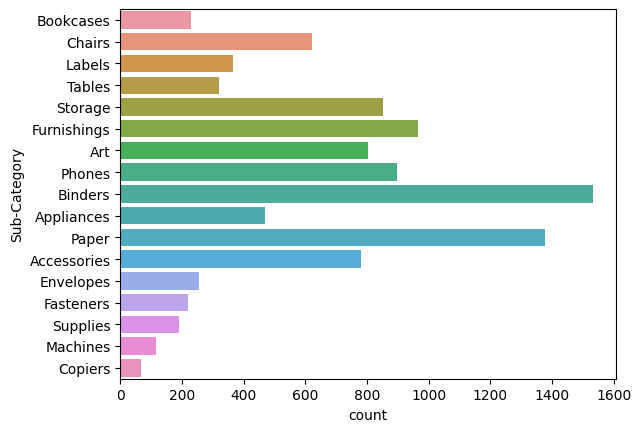

In [75]:
sns.countplot(data=df, y="Sub-Category")

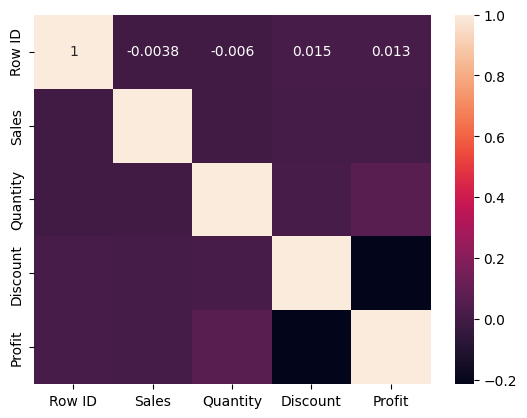

In [159]:
#Correlations !!!!!!!!!!
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()




<Axes: xlabel='Sales', ylabel='Profit'>

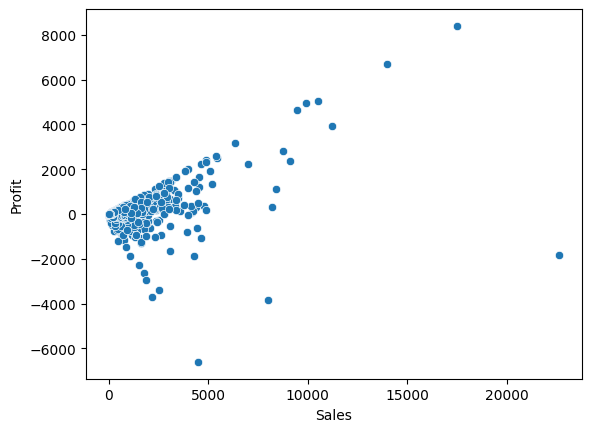

In [165]:
df1 = df[df['Sales']<1000000]
sns.scatterplot(data=df1 , x='Sales', y='Profit'  )

<Axes: xlabel='Order Date'>

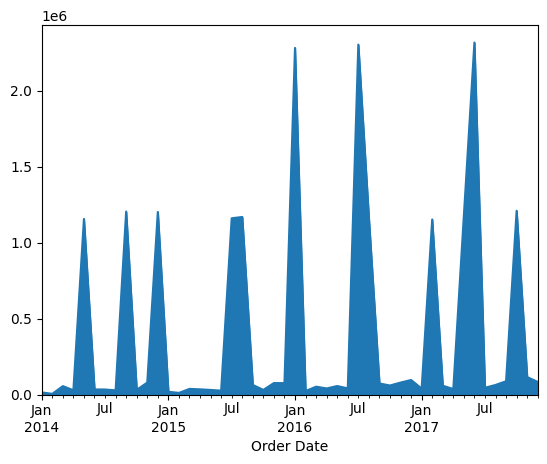

In [ ]:
#Business trends

#calculating sales by month
##changing the order date columns to datetime


df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
# df['Order Date'] = df['Order Date'].dt.strftime('%d-%m-%Y')

sales_by_month =  df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

# print(sales_by_month)

sales_by_month.plot(kind='line')



In [ ]:
# negative quantities
df[df['Quantity'] < 0]

In [ ]:
# > 100% discount
df[df['Discount'] > 100] # not found !

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [ ]:
# checking if order date > ship date
df[df['Order Date'] > df['Ship Date']]

In [ ]:
# df[df['Sales'] > 100000]
# df[df['Product Name']== 'Logitech G600 MMO Gaming Mouse'][['Product Name','Sales','Discount','Quantity']]

# sns.lineplot(data=df , x='Product Name' , y='Sales')


df_test = df.copy()

df_test['PU'] = df_test['Sales'] / (df_test['Quantity'] * (1- df_test['Discount']))

df_test[
    df_test["Product Name"] == "Logitech G600 MMO Gaming Mouse"
][
    ["Product Name", "Sales", "Discount", "Quantity", "PU"]
]

Q1 = df_test.groupby('Product Name')['PU'].transform("quantile", 0.25)
Q3 = df_test.groupby('Product Name')['PU'].transform("quantile", 0.75)
IQR = Q3 - Q1

#lower limit
lower = Q1 - 1.5*IQR

#upper limit
upper = Q3 - 1.5*IQR


outliers = (df_test['PU'] < lower) | (df_test['PU'] > upper)


# df_test[outliers][
#     ["Product Name", "Sales", "Quantity", "Discount", "PU"]
# ]

# print(lower)








0        130.980
1        243.980
2          7.310
3        348.210
4         13.980
          ...   
10059     92.800
10060     73.850
10061    -37.485
10062     60.890
10063     14.980
Name: PU, Length: 10064, dtype: float64
